# Pokémon TCG Deck Image Renderer

This notebook creates deck images from a 60-card deck list.

It is designed for **The Pokémon Company - PTCG AI Battle Challenge Simulation**.

The goal is simple:

- define or read a deck
- write `deck.csv`
- extract only the needed card pages from the official PDF
- create English and Japanese deck images

This notebook does **not** generate new card art.  
It only crops card images from the official PDF files and arranges them into one image.


## Deck setup

There are two ways to provide a deck.

1. Use a hardcoded Python list of 60 Card IDs.
2. Read an existing `deck.csv`.

For a first notebook, the hardcoded list is usually easiest.  
When you test many decks, keeping each deck as a separate `deck.csv` can be more convenient.


In [ ]:
!pip install pymupdf

In [ ]:
import os
from pathlib import Path

USE_EXTERNAL_DECK_CSV = False

# EXTERNAL_DECK_CANDIDATES = [
#     "/kaggle/input/datasets/kiyotah/mega-lucario-ex-deck/deck.csv",
#     "/kaggle/input/mega-lucario-ex-deck/deck.csv",
#     "deck.csv",
# ]

HARD_CODED_DECK = [
    741, 741, 741, 741, 742, 742, 742, 742, 743, 743, 743, 
    305, 305, 305, 66, 66, 140, 142, 858, 343, 
    1152, 1152, 1152, 1152, 1086, 1086, 1086, 1086, 1079, 1079, 1079, 
    1097, 1129, 1156, 1156, 1156, 1081, 1081, 1081, 1182, 1182, 
    1231, 1231, 1231, 1231, 1225, 1225, 1225, 1225, 1264, 1264, 1264, 1264, 
    5, 5, 19, 19, 19, 19, 13
]

if USE_EXTERNAL_DECK_CSV:
    deck_path = next((p for p in EXTERNAL_DECK_CANDIDATES if os.path.exists(p)), None)
    if deck_path is None:
        raise FileNotFoundError(
            "No external deck.csv was found. "
            "Set USE_EXTERNAL_DECK_CSV = False or add a dataset containing deck.csv."
        )

    with open(deck_path, "r", encoding="utf-8") as f:
        deck = [int(x) for x in f.read().splitlines() if x.strip()]
    deck_source = deck_path
else:
    deck = list(HARD_CODED_DECK)
    deck_source = "HARD_CODED_DECK"

if len(deck) != 60:
    raise ValueError(f"A deck must contain exactly 60 cards, but got {len(deck)} cards.")

with open("deck.csv", "w", encoding="utf-8") as f:
    for card_id in deck:
        f.write(f"{int(card_id)}\n")

print("Deck source:", deck_source)
print("Deck size:", len(deck))
print("First 10 Card IDs:", deck[:10])
print("deck.csv written to:", Path("deck.csv").resolve())


## Important note about the card CSV files

`deck.csv` is simple.  
It is just a 60-line list of Card IDs, so reading it with `splitlines()` is fine.

The official card data CSV files are different.

They can contain quoted multiline text, for example an effect explanation with line breaks inside one CSV field.  
So we should **not** parse the card data CSV with `splitlines()`.

This notebook reads card data with `pandas.read_csv`, which understands quoted multiline CSV fields.


## Deck image settings

The paths below assume the competition dataset is attached to the Kaggle Notebook.

The key assumption is:

> PDF page 40 is the first unique card in the card CSV.

The page number here is human-style, 1-indexed.  
Python PDF libraries use 0-indexed page indices internally, so the code handles that conversion.


In [ ]:
from pathlib import Path

COMPETITION_INPUT_DIR = Path("/kaggle/input/competitions/pokemon-tcg-ai-battle")

CARD_CSV_EN = COMPETITION_INPUT_DIR / "EN_Card_Data.csv"
CARD_CSV_JP = COMPETITION_INPUT_DIR / "JP_Card_Data.csv"

CARD_PDF_EN = COMPETITION_INPUT_DIR / "Card_ID List_EN.pdf"
CARD_PDF_JP = COMPETITION_INPUT_DIR / "Card_ID List_JP.pdf"

# Human-readable PDF page number.
# If PDF page 40 corresponds to the first unique Card ID in the CSV, keep this as 40.
PDF_CARD_START_PAGE = 40

OUTPUT_EN = Path("deck_en.jpg")
OUTPUT_JP = Path("deck_jp.jpg")

GRID_COLUMNS = 8
CARD_DISPLAY_WIDTH = 320
GRID_GAP = 8
GRID_PADDING = 0

LABEL_ALPHA = 180
PAGE_RENDER_ZOOM = 4.0

# JPG output settings
MAX_OUTPUT_BYTES = 1_000_000  # 1MB
JPEG_START_QUALITY = 88
JPEG_MIN_QUALITY = 45
JPEG_DOWNSCALE_STEP = 0.92
JPEG_MIN_WIDTH = 1200

print("English CSV:", CARD_CSV_EN)
print("Japanese CSV:", CARD_CSV_JP)
print("English PDF:", CARD_PDF_EN)
print("Japanese PDF:", CARD_PDF_JP)
print("Output EN:", OUTPUT_EN.resolve())
print("Output JP:", OUTPUT_JP.resolve())


## Helper functions

The functions below do four things:

1. Get the deck from the notebook variable `deck`, or from `deck.csv`.
2. Read the card data CSV safely.
3. Convert Card IDs to PDF page indices.
4. Crop card images from the PDF and render a deck grid.


In [ ]:
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown


def resolve_deck_ids(deck_csv_path="deck.csv"):
    """Return the 60-card deck list.

    Priority:
    1. Use the notebook variable named `deck` if it exists.
    2. Otherwise read deck.csv.

    This makes the renderer work with both hardcoded decks and external deck.csv files.
    """
    if "deck" in globals():
        deck_ids = list(globals()["deck"])
        source = "notebook variable: deck"
    else:
        deck_csv_path = Path(deck_csv_path)
        if not deck_csv_path.exists():
            raise FileNotFoundError(
                "No notebook variable named `deck` was found, and deck.csv does not exist."
            )
        with open(deck_csv_path, "r", encoding="utf-8") as f:
            deck_ids = [line.strip() for line in f.read().splitlines() if line.strip()]
        source = str(deck_csv_path)

    try:
        deck_ids = [int(x) for x in deck_ids]
    except Exception as e:
        raise ValueError("Deck must contain Card IDs that can be converted to integers.") from e

    if len(deck_ids) != 60:
        raise ValueError(f"A deck must contain exactly 60 cards, but got {len(deck_ids)} cards.")

    return deck_ids, source


def ordered_deck_counts(deck_ids):
    """Count Card IDs while preserving first appearance order."""
    counts = Counter(deck_ids)
    ordered_ids = []
    seen = set()

    for card_id in deck_ids:
        if card_id not in seen:
            ordered_ids.append(card_id)
            seen.add(card_id)

    return ordered_ids, counts


def normalize_column_name(name):
    """Normalize a column name for safer matching.

    This helps with small differences such as:
    - BOM
    - leading/trailing spaces
    - half-width spaces
    - full-width spaces
    """
    return (
        str(name)
        .strip()
        .lstrip("\ufeff")
        .replace(" ", "")
        .replace("　", "")
        .lower()
    )


def find_column(df, candidates, label):
    """Find a column by trying exact and normalized matching."""
    columns = list(df.columns)

    cleaned_to_original = {
        str(col).strip().lstrip("\ufeff"): col
        for col in columns
    }

    for candidate in candidates:
        if candidate in cleaned_to_original:
            return cleaned_to_original[candidate]

    normalized_to_original = {
        normalize_column_name(col): col
        for col in columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_column_name(candidate)
        if normalized_candidate in normalized_to_original:
            return normalized_to_original[normalized_candidate]

    raise ValueError(
        f"{label} column was not found. "
        f"Candidates: {candidates}. "
        f"Columns found: {columns}"
    )


def read_card_data_csv(csv_path):
    """Read official Card Data CSV safely.

    The official CSV may contain quoted multiline fields.
    Do not parse it with splitlines().

    This function supports both English and Japanese column names.

    English:
      - Card ID
      - Card Name

    Japanese:
      - カード ID
      - カード名
    """
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"Card data CSV not found: {csv_path}")

    errors = []

    for engine in ["c", "python"]:
        try:
            df = pd.read_csv(
                csv_path,
                encoding="utf-8-sig",
                keep_default_na=False,
                engine=engine,
            )
            break
        except Exception as e:
            errors.append(f"engine={engine}: {repr(e)}")
    else:
        raise RuntimeError(
            "Could not parse card data CSV. Errors:\n" + "\n".join(errors)
        )

    df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]

    card_id_col = find_column(
        df,
        candidates=[
            "Card ID",
            "カード ID",
            "カードID",
        ],
        label="Card ID",
    )

    try:
        card_name_col = find_column(
            df,
            candidates=[
                "Card Name",
                "カード名",
            ],
            label="Card Name",
        )
    except ValueError:
        card_name_col = None

    card_id_numeric = pd.to_numeric(df[card_id_col], errors="coerce")
    valid = card_id_numeric.notna()

    if not valid.any():
        raise ValueError(f"No valid Card ID values were found in {csv_path}")

    df = df.loc[valid].copy()
    df["Card ID"] = card_id_numeric.loc[valid].astype(int)

    if card_name_col is not None:
        df["Card Name"] = df[card_name_col].astype(str)
    else:
        df["Card Name"] = ""

    return df


def load_unique_card_order(csv_path):
    """Return unique Card IDs in first appearance order.

    The card data CSV can have multiple rows for one Card ID because one card can have
    multiple attacks or effects. The PDF order should correspond to unique Card IDs,
    not raw CSV rows.
    """
    df = read_card_data_csv(csv_path)

    unique_df = df.drop_duplicates(subset=["Card ID"], keep="first").reset_index(drop=True)
    unique_card_ids = unique_df["Card ID"].astype(int).tolist()

    card_id_to_order = {
        card_id: i
        for i, card_id in enumerate(unique_card_ids)
    }

    card_names = dict(
        zip(
            unique_df["Card ID"].astype(int),
            unique_df["Card Name"].astype(str),
        )
    )

    return unique_card_ids, card_id_to_order, card_names, len(df)


def build_card_id_to_pdf_page_index(deck_unique_ids, card_id_to_order, pdf_card_start_page=40):
    """Map Card ID to 0-indexed PDF page index."""
    missing = [
        card_id
        for card_id in deck_unique_ids
        if card_id not in card_id_to_order
    ]

    if missing:
        raise ValueError(
            "These deck Card IDs were not found in the card data CSV: "
            + ", ".join(map(str, missing))
        )

    # pdf_card_start_page is 1-indexed.
    start_page_index = pdf_card_start_page - 1

    return {
        card_id: start_page_index + card_id_to_order[card_id]
        for card_id in deck_unique_ids
    }


def import_pymupdf():
    """Import PyMuPDF with a beginner-friendly error message."""
    try:
        import fitz
        return fitz
    except Exception as e:
        raise ImportError(
            "PyMuPDF is required to render PDF pages. "
            "In Kaggle, try adding a cell with `pip install pymupdf` if it is not available."
        ) from e


def render_pdf_page_to_image(doc, page_index, zoom=4.0):
    """Render one PDF page to a PIL RGB image."""
    if page_index < 0 or page_index >= len(doc):
        raise IndexError(
            f"PDF page index out of range: {page_index}. "
            f"The PDF has {len(doc)} pages."
        )

    page = doc.load_page(page_index)
    fitz = import_pymupdf()
    matrix = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=matrix, alpha=False)

    img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    return img


def crop_card_from_page_image(page_img, expected_card_aspect=0.714):
    """Crop the card image from a rendered PDF page.

    The official PDF page is mostly white, with one card near the upper-middle area.

    This version is intentionally a little stricter than a simple bounding box.
    It tries to remove extra white margins on the left and right, then enforces
    a Pokémon-card-like portrait aspect ratio.
    """
    img = page_img.convert("RGB")
    arr = np.asarray(img)

    h, w = arr.shape[:2]

    # Search only where the card is expected to be.
    # The bottom note text is intentionally excluded.
    x0 = int(w * 0.05)
    x1 = int(w * 0.95)
    y0 = int(h * 0.02)
    y1 = int(h * 0.72)

    roi = arr[y0:y1, x0:x1, :]

    # Difference from white background.
    # This is more stable than checking one channel only.
    darkness = np.max(255 - roi.astype(np.int16), axis=2)

    # Card art/text/border should differ from the white PDF background.
    mask = darkness > 18

    row_counts = mask.sum(axis=1)
    col_counts = mask.sum(axis=0)

    if row_counts.max() <= 0 or col_counts.max() <= 0:
        # Fallback crop based on the sample layout.
        left = int(w * 0.36)
        right = int(w * 0.64)
        top = int(h * 0.07)
        bottom = int(h * 0.62)
    else:
        # Use density thresholds instead of a raw bounding box.
        # This avoids tiny text/noise expanding the crop.
        row_threshold = max(10, int(row_counts.max() * 0.055))
        col_threshold = max(10, int(col_counts.max() * 0.055))

        ys = np.where(row_counts > row_threshold)[0]
        xs = np.where(col_counts > col_threshold)[0]

        if len(xs) < 10 or len(ys) < 10:
            # Fallback crop based on the sample layout.
            left = int(w * 0.36)
            right = int(w * 0.64)
            top = int(h * 0.07)
            bottom = int(h * 0.62)
        else:
            left = x0 + int(xs.min())
            right = x0 + int(xs.max()) + 1
            top = y0 + int(ys.min())
            bottom = y0 + int(ys.max()) + 1

            # Add a small margin so the card border is not accidentally cut off.
            pad = max(8, int(max(w, h) * 0.004))
            left = max(0, left - pad)
            right = min(w, right + pad)
            top = max(0, top - pad)
            bottom = min(h, bottom + pad)

    # The most common failure mode is that the crop is too wide because the page
    # contains a little non-white noise. We tighten the width toward the expected
    # Pokémon card aspect ratio.
    box_w = right - left
    box_h = bottom - top

    if box_w <= 0 or box_h <= 0:
        raise RuntimeError("Invalid crop box. Check the PDF page mapping or crop logic.")

    current_aspect = box_w / box_h
    center_x = (left + right) / 2

    # If crop is too wide, shrink horizontally around the detected center.
    if current_aspect > expected_card_aspect * 1.18:
        target_w = int(round(box_h * expected_card_aspect))
        left = int(round(center_x - target_w / 2))
        right = left + target_w

    # If crop is too narrow, expand horizontally. This is safer than cropping height.
    elif current_aspect < expected_card_aspect * 0.82:
        target_w = int(round(box_h * expected_card_aspect))
        left = int(round(center_x - target_w / 2))
        right = left + target_w

    # Clamp to page bounds.
    if left < 0:
        right -= left
        left = 0

    if right > w:
        shift = right - w
        left = max(0, left - shift)
        right = w

    # Final tiny padding. At high zoom this keeps the border safe without bringing
    # back large side margins.
    final_pad = max(2, int(max(w, h) * 0.0015))
    left = max(0, left - final_pad)
    right = min(w, right + final_pad)
    top = max(0, top - final_pad)
    bottom = min(h, bottom + final_pad)

    cropped = img.crop((left, top, right, bottom))

    if cropped.width < 50 or cropped.height < 80:
        raise RuntimeError(
            f"Card crop looks too small: {cropped.size}. "
            "Check PDF_CARD_START_PAGE or the crop logic."
        )

    return cropped


def extract_card_images_from_pdf(pdf_path, card_id_to_page_index, zoom=4.0):
    """Extract only the PDF pages needed by the deck."""
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"Card PDF not found: {pdf_path}")

    fitz = import_pymupdf()
    images = {}

    with fitz.open(pdf_path) as doc:
        for card_id, page_index in card_id_to_page_index.items():
            page_img = render_pdf_page_to_image(doc, page_index, zoom=zoom)
            card_img = crop_card_from_page_image(page_img)
            images[card_id] = card_img

    return images


def get_font(size):
    """Get a readable font. Fall back to PIL default if needed."""
    font_candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
    ]

    for font_path in font_candidates:
        if Path(font_path).exists():
            try:
                return ImageFont.truetype(font_path, size=size)
            except Exception:
                pass

    return ImageFont.load_default()


def resize_keep_aspect(img, target_width):
    """Resize an image while preserving aspect ratio."""
    resampling = getattr(Image, "Resampling", Image).LANCZOS
    target_width = int(target_width)
    scale = target_width / img.width
    target_height = max(1, int(round(img.height * scale)))
    return img.resize((target_width, target_height), resampling)


def text_bbox(draw, xy, text, font):
    """Compatibility wrapper for text bounding box."""
    if hasattr(draw, "textbbox"):
        return draw.textbbox(xy, text, font=font)

    w, h = draw.textsize(text, font=font)
    x, y = xy
    return (x, y, x + w, y + h)


def make_labeled_card_tile(card_img, card_id, count, card_width=320, label_alpha=180):
    """Create one card tile with a translucent centered label at the bottom."""
    card = resize_keep_aspect(card_img, card_width).convert("RGBA")

    label_h = max(48, int(card.height * 0.155))

    overlay = Image.new("RGBA", card.size, (0, 0, 0, 0))
    overlay_draw = ImageDraw.Draw(overlay)
    overlay_draw.rectangle(
        [0, card.height - label_h, card.width, card.height],
        fill=(0, 0, 0, int(label_alpha)),
    )

    tile = Image.alpha_composite(card, overlay)
    draw = ImageDraw.Draw(tile)

    text = f"×{count}  ID:{card_id}"

    font_size = max(24, int(label_h * 0.62))
    font = get_font(font_size)

    # Shrink text if it is too wide.
    max_text_width = int(card.width * 0.94)

    while font_size > 10:
        bbox = text_bbox(draw, (0, 0), text, font)
        text_w = bbox[2] - bbox[0]

        if text_w <= max_text_width:
            break

        font_size -= 1
        font = get_font(font_size)

    bbox = text_bbox(draw, (0, 0), text, font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    # Center the label text horizontally.
    x = (card.width - text_w) // 2
    y = card.height - label_h + (label_h - text_h) // 2 - 1

    # A tiny stroke helps readability on the translucent label.
    try:
        draw.text(
            (x, y),
            text,
            fill=(255, 255, 255, 255),
            font=font,
            stroke_width=max(1, int(font_size * 0.035)),
            stroke_fill=(0, 0, 0, 230),
        )
    except TypeError:
        draw.text((x, y), text, fill=(255, 255, 255, 255), font=font)

    return tile


def render_deck_grid(
    ordered_ids,
    counts,
    card_images,
    columns=8,
    card_width=320,
    gap=8,
    padding=0,
    label_alpha=180,
):
    """Render all unique deck cards into one black-background image."""
    tiles = []

    for card_id in ordered_ids:
        if card_id not in card_images:
            raise KeyError(f"Missing extracted image for Card ID {card_id}")

        tile = make_labeled_card_tile(
            card_images[card_id],
            card_id=card_id,
            count=counts[card_id],
            card_width=card_width,
            label_alpha=label_alpha,
        )

        tiles.append((card_id, tile))

    if not tiles:
        raise ValueError("No cards to render.")

    columns = max(1, int(columns))
    rows = math.ceil(len(tiles) / columns)

    tile_w = max(tile.width for _, tile in tiles)
    tile_h = max(tile.height for _, tile in tiles)

    width = padding * 2 + columns * tile_w + (columns - 1) * gap
    height = padding * 2 + rows * tile_h + (rows - 1) * gap

    canvas = Image.new("RGB", (width, height), (0, 0, 0))

    for idx, (card_id, tile) in enumerate(tiles):
        row = idx // columns
        col = idx % columns

        cell_x = padding + col * (tile_w + gap)
        cell_y = padding + row * (tile_h + gap)

        # Center each tile inside its cell.
        # This matters if a few cards have slightly different extracted aspect ratios.
        x = cell_x + (tile_w - tile.width) // 2
        y = cell_y + (tile_h - tile.height) // 2

        canvas.paste(tile.convert("RGB"), (x, y))

    return canvas
    
def save_jpeg_under_size(
    image,
    output_path,
    max_bytes=1_000_000,
    start_quality=88,
    min_quality=45,
    downscale_step=0.92,
    min_width=1200,
):
    """Save image as JPEG under the target file size.

    Strategy:
    1. Try lowering JPEG quality.
    2. If still too large, downscale the image a little.
    3. Repeat until the file is under max_bytes or the image becomes too small.

    Returns:
        saved_image: the image that was actually saved
        final_quality: JPEG quality used
        final_size_bytes: output file size
    """
    output_path = Path(output_path)

    resampling = getattr(Image, "Resampling", Image).LANCZOS

    # JPEG does not support alpha.
    working = image.convert("RGB")

    while True:
        for quality in range(start_quality, min_quality - 1, -5):
            working.save(
                output_path,
                format="JPEG",
                quality=quality,
                optimize=True,
                progressive=True,
                subsampling=2,
            )

            size_bytes = output_path.stat().st_size

            if size_bytes <= max_bytes:
                return working, quality, size_bytes

        # If quality reduction is not enough, downscale and try again.
        if working.width <= min_width:
            # Save the best effort version at min_quality.
            working.save(
                output_path,
                format="JPEG",
                quality=min_quality,
                optimize=True,
                progressive=True,
                subsampling=2,
            )
            size_bytes = output_path.stat().st_size

            if size_bytes > max_bytes:
                print(
                    f"Warning: Could not get under {max_bytes:,} bytes "
                    f"without shrinking below min_width={min_width}. "
                    f"Final size: {size_bytes:,} bytes."
                )

            return working, min_quality, size_bytes

        new_width = max(min_width, int(working.width * downscale_step))
        scale = new_width / working.width
        new_height = max(1, int(round(working.height * scale)))

        working = working.resize((new_width, new_height), resampling)

def render_deck_image_for_language(
    deck_ids,
    language_label,
    card_csv_path,
    card_pdf_path,
    output_path,
    pdf_card_start_page=40,
    columns=8,
    card_width=320,
    gap=8,
    padding=0,
    label_alpha=180,
    page_render_zoom=4.0,
    max_output_bytes=1_000_000,
    jpeg_start_quality=88,
    jpeg_min_quality=45,
    jpeg_downscale_step=0.92,
    jpeg_min_width=1200,
):
    """Create one compressed JPG deck image for one language."""
    ordered_ids, counts = ordered_deck_counts(deck_ids)

    unique_card_ids, card_id_to_order, card_names, raw_rows = load_unique_card_order(card_csv_path)

    card_id_to_page_index = build_card_id_to_pdf_page_index(
        ordered_ids,
        card_id_to_order,
        pdf_card_start_page=pdf_card_start_page,
    )

    print(f"\n[{language_label}]")
    print("Card data rows loaded:", raw_rows)
    print("Unique Card IDs:", len(unique_card_ids))
    print("Deck unique Card IDs:", len(ordered_ids))
    print("PDF card start page:", pdf_card_start_page)
    print("Card display width:", card_width)
    print("PDF render zoom:", page_render_zoom)
    print("Target JPG size:", f"{max_output_bytes:,} bytes")
    print("First few deck mappings:")

    for card_id in ordered_ids[:8]:
        page_index = card_id_to_page_index[card_id]
        page_1indexed = page_index + 1
        name = card_names.get(card_id, "")
        print(f"  ID {card_id} -> PDF page {page_1indexed}  {name}")

    card_images = extract_card_images_from_pdf(
        card_pdf_path,
        card_id_to_page_index,
        zoom=page_render_zoom,
    )

    deck_image = render_deck_grid(
        ordered_ids,
        counts,
        card_images,
        columns=columns,
        card_width=card_width,
        gap=gap,
        padding=padding,
        label_alpha=label_alpha,
    )

    output_path = Path(output_path)

    saved_image, final_quality, final_size_bytes = save_jpeg_under_size(
        deck_image,
        output_path=output_path,
        max_bytes=max_output_bytes,
        start_quality=jpeg_start_quality,
        min_quality=jpeg_min_quality,
        downscale_step=jpeg_downscale_step,
        min_width=jpeg_min_width,
    )

    print("Saved:", output_path.resolve())
    print("Original image size:", deck_image.size)
    print("Saved image size:", saved_image.size)
    print("JPEG quality:", final_quality)
    print("File size:", f"{final_size_bytes:,} bytes")

    return saved_image

## Render English and Japanese deck images

This cell creates:

- `deck_en.jpg`
- `deck_jp.jpg`

Only the Card IDs that appear in the deck are processed.  
The notebook does not scan every PDF page.


In [ ]:
deck_ids, resolved_deck_source = resolve_deck_ids()

print("Resolved deck source:", resolved_deck_source)
print("Deck size:", len(deck_ids))
print("Unique cards:", len(set(deck_ids)))

deck_image_en = render_deck_image_for_language(
    deck_ids=deck_ids,
    language_label="EN",
    card_csv_path=CARD_CSV_EN,
    card_pdf_path=CARD_PDF_EN,
    output_path=OUTPUT_EN,
    pdf_card_start_page=PDF_CARD_START_PAGE,
    columns=GRID_COLUMNS,
    card_width=CARD_DISPLAY_WIDTH,
    gap=GRID_GAP,
    padding=GRID_PADDING,
    label_alpha=LABEL_ALPHA,
    page_render_zoom=PAGE_RENDER_ZOOM,
    max_output_bytes=MAX_OUTPUT_BYTES,
    jpeg_start_quality=JPEG_START_QUALITY,
    jpeg_min_quality=JPEG_MIN_QUALITY,
    jpeg_downscale_step=JPEG_DOWNSCALE_STEP,
    jpeg_min_width=JPEG_MIN_WIDTH,
)

deck_image_jp = render_deck_image_for_language(
    deck_ids=deck_ids,
    language_label="JP",
    card_csv_path=CARD_CSV_JP,
    card_pdf_path=CARD_PDF_JP,
    output_path=OUTPUT_JP,
    pdf_card_start_page=PDF_CARD_START_PAGE,
    columns=GRID_COLUMNS,
    card_width=CARD_DISPLAY_WIDTH,
    gap=GRID_GAP,
    padding=GRID_PADDING,
    label_alpha=LABEL_ALPHA,
    page_render_zoom=PAGE_RENDER_ZOOM,
    max_output_bytes=MAX_OUTPUT_BYTES,
    jpeg_start_quality=JPEG_START_QUALITY,
    jpeg_min_quality=JPEG_MIN_QUALITY,
    jpeg_downscale_step=JPEG_DOWNSCALE_STEP,
    jpeg_min_width=JPEG_MIN_WIDTH,
)

# Direct display may embed large base64 image data into the notebook.
print()
print("Deck images were saved as files:")
print("EN:", OUTPUT_EN.resolve())
print("JP:", OUTPUT_JP.resolve())

## Output files

The generated images are saved under the notebook working directory.

In Kaggle Notebooks, this usually means:

- `/kaggle/working/deck_en.jpg`
- `/kaggle/working/deck_jp.jpg`

These images are only for understanding and explanation.  
They do not need to be included in `submission.tar.gz`.

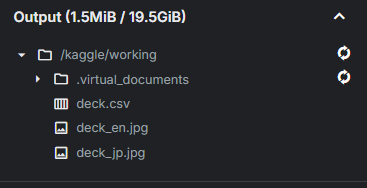
